# Texas Childcare: Compliance Records vs. Family Experience
## Notebook 01 — Model 1: Compliance Features (XGBoost + SHAP)

**Author:** Rakesh Chandrasekaran
**Program:** Professional Certificate in ML and AI, UC Berkeley
**Date:** June 2026

---

## Research Question

**Do Texas HHSC compliance records and families' Google reviews agree on which daycare centers are high quality — and can a parent rely on compliance records alone to make an informed childcare decision?**

This project builds two predictive models. The first uses HHSC regulatory inspection features; the second uses the text of families' own Google reviews. Both models predict a center's Google star rating — both the exact rating (regression) and whether a center is rated excellent by families (4.5 stars and above, classification). Comparing the two models reveals how closely compliance data and family experience track each other, and whether a parent consulting only inspection records would reach the same conclusion as one who reads reviews.

---

## Who This Project Serves

| Stakeholder | Question |
|---|---|
| **Parents (primary)** | Do HHSC compliance records and Google reviews agree on which daycare centers are high quality — and can I rely on compliance records alone to choose a center? |
| **Compliance officers** | Does our inspection framework measure what families actually care about? |
| **Daycare operators** | Which compliance factors should I focus on to improve how families rate my center? |

---

## Cities in Scope
Austin · Houston · San Antonio · Dallas · Fort Worth

---

### This Notebook
Trains XGBoost regression and classification models on 15 HHSC regulatory compliance features. Uses iterative 3-round grid search for hyperparameter tuning. Includes SHAP feature importance and city interaction analysis. 
Saves outputs to `model1_outputs.pkl`.

### Notebook Structure
0. Setup and Data Loading
    - Imports, constants, directory config
    - Load model1_dataset.csv
1. Design Decisions (6 documented choices with justification)
2. Data Preparation
    - Train/test split
    - Binary labels: HIGH_RATED = google_rating ≥ 4.5
    - Sample weights: review count reliability (Design Decision 3)
3. Model 1 — Compliance Features → Star Ratings
    - 3.0 XGBoost Shared Preprocessor (ColumnTransformer + Pipeline)
    - 3A. Regression
        - XGBoost (iterative grid search, 3 rounds) → Test evaluation
        - Ridge re-baseline → Rounds 1/2/3 → Test evaluation
    - 3B. Classification 
        - XGBoost (iterative grid search, 3 rounds) → Test evaluation
        - DummyClassifier + LR baselines → Rounds 1/2/3 → Test evaluation
        - Confusion matrix + ROC
    - 3C. SHAP Feature Importance (all 19 features)
    - 3D. SHAP City Interaction Analysis (compliance × city heatmap)
4. Save Outputs — Handoff to Notebooks 02, 03, 04
    - Saves model1_outputs.pkl: metrics, predictions, train/test center IDs

## 0. Setup and Data Loading

In [1]:
# ── Libraries ────────────────────────────────────────────────────────────
import os, pickle
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ── Visualisation ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")
from matplotlib.patches import Patch

# ── Scikit-learn: preprocessing, pipelines, model selection ─────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, f1_score,
    RocCurveDisplay, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score
)

# ── XGBoost and SHAP ─────────────────────────────────────────────────────
from xgboost import XGBClassifier, XGBRegressor
import shap

# ── Reproducibility and paths ─────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
THRESHOLD    = 4.5   # center-level: google_rating >= 4.5 = HIGH_RATED
M2_THRESHOLD = 4     # individual review: review_rating >= 4 = HIGH_RATED (Model 2B)

# ── Directory configuration ───────────────────────────────────────────────
BASE_DIR  = os.getcwd()
IMAGE_DIR = os.path.join(BASE_DIR, "images", "models")
PROC_DIR  = os.path.join(BASE_DIR, "data", "processed")
os.makedirs(IMAGE_DIR, exist_ok=True)

# ── Load dataset (exported by Notebook 00, Section 13.1) ─────────────────
df_model1 = pd.read_csv(os.path.join(PROC_DIR, "model1_dataset.csv"))

print(f"Model 1 dataset loaded: {len(df_model1):,} centers, {df_model1.shape[1]} columns")
print(f"Images -> {IMAGE_DIR}")
print("Feature definition, train/test split and labels are in Section 2.")


Model 1 dataset loaded: 1,697 centers, 27 columns
Images -> /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/images/models
Feature definition, train/test split and labels are in Section 2.


## 1. Design Decisions

Five deliberate choices were made before model training. Each is explained in full in the cells below.

| # | Decision | Summary |
|---|---|---|
| 1 | Binary label threshold | 4.5 stars for all center-level models (Model 1, Model 2A, Model 2B); 4 stars applies only to individual review baselines in Notebook 03 |
| 2 | Evaluation metric | F1 + AUC-ROC because accuracy misleads with imbalanced class distributions |
| 3 | Sample weights | Review count reliability weighted into Model 1 and Model 2A training; not needed for Model 2B individual reviews |
| 4 | Recency weighting | Both recency-weighted and simple mean tested; simple mean (AUC=0.8034) outperformed recency-weighted (AUC=0.7638) — simple mean used as primary |
| 5 | Model 2 granularity | Center-level text for Model 2A; individual reviews with center-aligned labels for Model 2B |
| 6 | City as fixed effect | CITY one-hot encoded to control for city-level rating differences; city dummies dominate all compliance features |


**Decision 1: Binary label threshold: 4.5 stars for all center-level models**

Childcare is not a commodity. Quality directly affects a child's safety, development, and wellbeing. A parent choosing daycare does not settle for "acceptable"; they look for centers that other families consistently rate as excellent. The median Google rating across the 1,697 centers in this dataset is 4.60, and 59.9% of centers rate at 4.5 or above (full rating distribution analysis in `00-data-collection-preparation-eda.ipynb`). A threshold of 4.5 separates genuinely excellent centers from the rest and produces a workable class split of 59.9% HIGH_RATED vs 40.1% LOW_RATED. A threshold of 4.0 would classify 86.2% of centers as high-rated, leaving only 234 centers in the low-rated class. That is too few for the model to learn meaningful patterns. Centers rated 4.5 or above are labelled `HIGH_RATED = 1`; below 4.5 are `HIGH_RATED = 0`.

The primary Model 2B (Notebook 03, Section 4G) also uses the 4.5-star threshold. Individual reviews are labeled using each center's google_rating — if the center is rated 4.5 or above, all its reviews are labeled HIGH_RATED. This ensures a consistent threshold across all center-level models and makes the comparison in Notebook 04 valid.

The 4-star threshold applies only to the individual review baselines retained in Notebook 03 (Sections 4B-4D) for comparison purposes. These models were trained to classify individual reviewer sentiment (review_rating ≥ 4 = positive experience), not center-level quality, and are not the primary Model 2B comparison to Model 1.

The rating distribution below confirms 4.5 as the natural classification boundary.

![Google Rating Distribution — All 5 Cities (n=1,697)](images/eda/eda_11_1_target_distribution.png)
*Source: `images/eda/eda_11_1_target_distribution.png`, generated in `00-data-collection-preparation-eda.ipynb` Section 11.1*

**Decision 2: Evaluation metric: F1 + AUC-ROC, not accuracy**

Accuracy is misleading when one class is much larger than the other. In this dataset, 59.9% of centers are HIGH_RATED. A model that simply predicts everything as HIGH_RATED, without looking at any features, would score 59.9% accuracy while learning nothing useful. The same problem is worse for individual review classification (Model 2B), where 88.7% of reviews are HIGH_RATED; a trivial majority predictor achieves 88.7% accuracy automatically.

Two metrics are used instead:

**F1 score** forces the model to perform on both classes. If a model never identifies any LOW_RATED centers, it scores F1 = 0 for that class regardless of how many HIGH_RATED centers it gets right. This directly measures what matters for the research question: can the model identify poor-quality centers, not just confirm the obvious majority?

**AUC-ROC** asks whether the model correctly ranks a HIGH_RATED center above a LOW_RATED center. A random model scores 0.50. Any score above 0.50 means the model learned a real signal. Unlike accuracy or F1, AUC-ROC does not depend on a specific decision threshold, making it ideal for comparing models that may use different thresholds.

Both metrics are used consistently across all models to enable direct comparison.

![HIGH_RATED vs LOW_RATED — Model 1 and Model 2B](images/models/rating_split_model1_model2.png)
*Source: `images/models/rating_split_model1_model2.png`, generated in Notebook 03 Section 0.4*

**Decision 3: Sample weights for review count reliability (Model 1 and Model 2A)**

A center's Google aggregate rating is computed from all reviews it has ever received. But the Google Places API returns at most 5 reviews per center. A center with only 2 reviews in our dataset has a 4.5-star average that could easily shift by a full star with one more review. A center with 500 total reviews has a stable 4.5-star average built on hundreds of data points. Both appear identical in the dataset as "4.5 stars" but they carry very different levels of confidence.

If both centers are weighted equally during training, the model learns as much from an unreliable 2-review label as from a solid 500-review label.

Sample weights solve this by giving centers more influence proportional to their review count. The formula is: `weight = min(review_count, 10) / 10`

- Centers with 10 or more reviews receive full weight (1.0). This covers 72.7% of centers.
- Centers with 5 reviews receive weight 0.50.
- Centers with 2 reviews receive weight 0.20.

Sample weights are applied to both **Model 1** (compliance features) and **Model 2A** (review text) since both use `google_rating` as the target variable and both face the same label reliability concern. Applying weights to one but not the other would make the comparison between them methodologically inconsistent.

Model 2B individual reviews do not need sample weights. Each individual review is a direct signal from one person with no aggregation involved, so there is no label reliability problem at the review level.

![Review Count Reliability and Sample Weights][def]
*Source: `images/models/review_count_reliability.png`, generated in Section 2 of this notebook*

[def]: images/models/review_count_reliability.png

**Decision 4: Model 2B aggregation — recency-weighted mean and simple mean compared**

When aggregating Model 2B's individual review predictions to center level, two aggregation methods were designed and compared: recency-weighted mean and simple mean.

**Recency-weighted mean** gives more influence to recent reviews, using exponential decay with a 2-year (730-day) half-life:

```python
recency_weight = exp(-days_since_review / 730)
```

`RECENCY_DATE` is set to April 1, 2026, just before data was collected. A review from 6 months ago receives approximately 78% of the weight of a current review. A review from 3 years ago receives approximately 22%. The 2-year half-life is chosen because daycare centers are stable businesses where quality persists over multiple years.

**Empirical finding:** Simple mean (AUC=0.8034) outperformed recency-weighted mean (AUC=0.7638) on the test set. With only 5 reviews per center (Google Places API cap), recency weighting amplifies noise rather than signal. Differentially weighting 5 data points is less stable than treating them equally. Simple mean is used as the primary Model 2B aggregation method. Recency-weighted mean results are also reported for transparency.

Review timestamps were re-fetched from the Google Places API for all 1,697 centers (see `00-data-collection-preparation-eda.ipynb` Section 13.2). Out of 7,550 reviews, 7,462 (98.8%) received timestamps and 88 (1.2%) could not be matched.

*Limitations: Google Places API returns at most 5 reviews per center. Google's formula also accounts for reviewer credibility and spam detection, which are not accessible via the public API.*

![Review Timestamps and Recency Weights](images/eda/eda_13_2_review_timestamps.png)
*Source: `images/eda/eda_13_2_review_timestamps.png`, generated in `00-data-collection-preparation-eda.ipynb` Section 13.2*

**Decision 5: Model 2 granularity — center-level text for Model 2A, individual reviews for Model 2B**

**Model 2A (regression and classification) uses center-level aggregated text** because the target is the center's aggregate Google rating — a single number per center. The input must match the level of the target. This means the same 1,697 centers, same train/test split, and same target as Model 1, giving a valid apples-to-apples comparison.

**Model 2B uses individual reviews with center-aligned labels.** All reviews from a center stay together in either train or test (center-aligned split). Each review is labeled with its center's google_rating (regression) or google_rating ≥ 4.5 (classification) — the same threshold as Model 1. This approach:

- Provides more training examples (7,550 review instances vs 1,697 centers)
- Uses the same labels and threshold as Model 1 for a valid comparison
- Tests whether training at the review level, then aggregating predictions to center level, matches or improves on direct center-level training

Model 2A asks: "How accurately does center-level review text predict the exact center rating?" Model 2B asks: "Does training at individual review level and aggregating to center level produce better predictions than center-level training?" Together they give a two-dimensional comparison with Model 1.

**Decision 6: CITY included as a fixed effect**

The five cities in this study differ in rating culture, family expectations, market density, and demographics. A model that ignores city entirely would confuse city-level effects with compliance effects — for example, if Dallas centers tend to receive lower ratings regardless of their inspection record, the model would incorrectly attribute that pattern to compliance features.

Three alternatives were considered and rejected:

- **Separate models per city:** Dallas (230 centers) and Fort Worth (164 centers) are too small to train reliable models independently. Splitting the data would reduce each training set by 80% or more.
- **Interaction features:** Multiplying CITY by each of the 15 compliance features would create up to 60 new columns and risk overfitting on 1,697 centers.
- **Hierarchical modeling:** The most statistically rigorous option, but requires a different framework. Identified as a future improvement.

**The chosen approach:** encode CITY as one-hot dummy variables. This lets the model learn a city-level baseline difference in ratings — essentially, "how does being in Dallas shift the predicted rating, all else equal?" — without increasing the feature space significantly.

The Ridge baseline analysis in the EDA notebook confirmed this mattered: city dummy coefficients dominated all 15 compliance features. ACCEPTS SUBSIDIES was the largest coefficient at -0.10 and CITY DALLAS was second at -0.085. Geography explains more rating variance than any individual inspection measure, making it essential to control for.

The plot below shows the Ridge coefficient magnitudes. SHAP interaction analysis in Section 3D of this notebook further quantifies how each city modifies each compliance feature's predictive effect.

![Ridge Regression Feature Coefficients — City Dummies Dominate](images/models/m1_baseline_12_5_3_feature_coefficients.png)
*Source: `images/models/m1_baseline_12_5_3_feature_coefficients.png`, generated in `00-data-collection-preparation-eda.ipynb`*

## 2. Data Preparation

Defines model inputs, splits data into train and test sets, derives binary labels from the split sets, and visualises the class distribution. All transformations (encoding, TF-IDF vectorisation) happen inside pipelines in Sections 3 and 4.


### 2.1 — Feature Definition

Declares the 15 HHSC regulatory features and the CITY variable used as inputs to Model 1.


In [2]:
# HAS_ADVERSE_ACTION and WAS_TEMP_CLOSED excluded — zero variance after filtering to active centers
NUMERIC_FEATURES = [
    'DEFICIENCY_HIGH', 'DEFICIENCY_MEDIUM_HIGH', 'DEFICIENCY_MEDIUM',
    'DEFICIENCY_MEDIUM_LOW', 'DEFICIENCY_LOW', 'TOTAL_DEFICIENCIES',
    'DEFICIENCY_RATE', 'HIGH_DEFICIENCY_RATE', 'TOTAL_CAPACITY',
    'TOTAL_INSPECTIONS', 'TOTAL_ASSESSMENTS', 'YEARS_IN_OPERATION',
    'IS_ACCREDITED', 'ACCEPTS_SUBSIDIES', 'HAS_CORRECTIVE_ACTION'
]
CATEGORICAL_FEATURES = ['CITY']
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Classification thresholds — defined here so all Section 2 cells can reference them
THRESHOLD    = 4.5  # All center-level models (Model 1, Model 2A, Model 2B): google_rating >= 4.5 = HIGH_RATED
M2_THRESHOLD = 4    # Individual review baselines only (Model 2B): review_rating >= 4 = HIGH_RATED

print(f'{len(NUMERIC_FEATURES)} numeric features + CITY categorical = {len(ALL_FEATURES)} total input features')
print(f'Center-level threshold (Model 1, 2A, 2B): {THRESHOLD} stars | Individual review baseline threshold: {M2_THRESHOLD} stars')


15 numeric features + CITY categorical = 16 total input features
Center-level threshold (Model 1, 2A, 2B): 4.5 stars | Individual review baseline threshold: 4 stars


### 2.2 — Class Distribution

Plots the HIGH_RATED vs LOW_RATED class balance for both models across the full dataset.


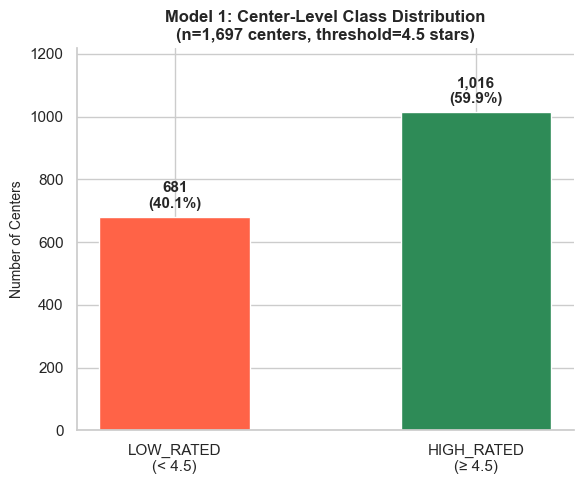

Model 1: 681 LOW_RATED (40.1%) | 1,016 HIGH_RATED (59.9%)


In [5]:
# Model 1 class distribution — imbalance is a data property, not a model output
# Model 2B class distribution is shown in Notebook 03
m1_counts = (df_model1['google_rating'] >= THRESHOLD).astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 5))
n = len(df_model1)
bars = ax.bar(['LOW_RATED\n(< 4.5)', 'HIGH_RATED\n(≥ 4.5)'],
              m1_counts.values, color=['tomato', 'seagreen'], edgecolor='white', width=0.5)
for bar, count in zip(bars, m1_counts.values):
    pct = count / n * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + n * 0.01,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title(f'Model 1: Center-Level Class Distribution\n(n={n:,} centers, threshold={THRESHOLD} stars)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Centers', fontsize=10)
ax.set_ylim(0, max(m1_counts.values) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'm1_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Model 1: {m1_counts[0]:,} LOW_RATED ({m1_counts[0]/n*100:.1f}%) | {m1_counts[1]:,} HIGH_RATED ({m1_counts[1]/n*100:.1f}%)')


### 2.3 — Review Count Reliability

Plots how rating reliability varies with review count to justify the sample weight formula.


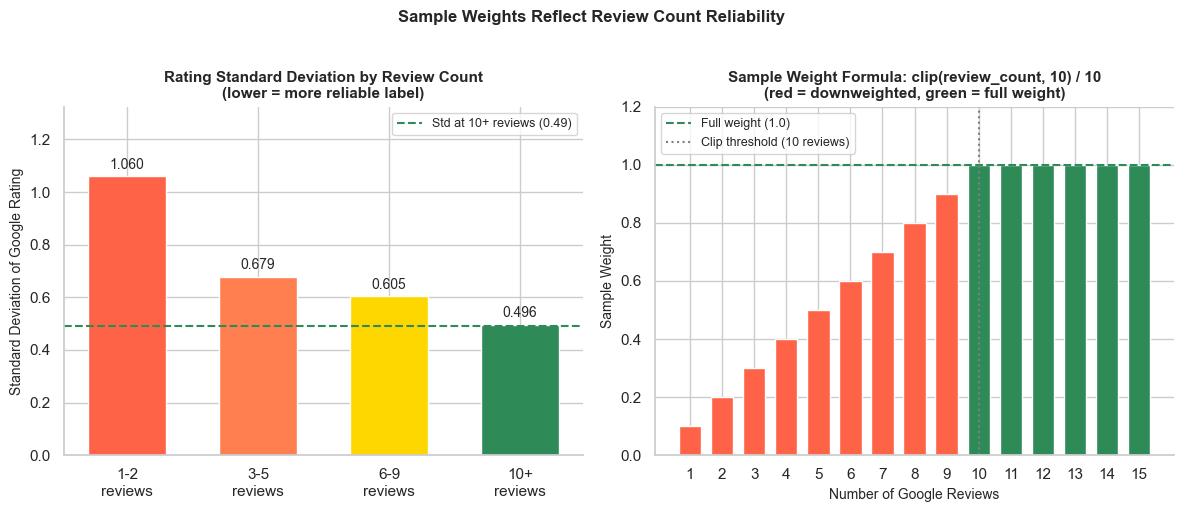

Saved: /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/images/models/review_count_reliability.png


In [6]:
# Rating std deviation drops with more reviews — justifies clipping sample weights at 10

rc   = df_model1['google_review_count']
rate = df_model1['google_rating']

buckets       = [0, 2, 5, 9, rc.max()]
bucket_labels = ['1-2\nreviews', '3-5\nreviews', '6-9\nreviews', '10+\nreviews']
stds = []
for lo, hi in zip(buckets, buckets[1:]):
    mask = (rc > lo) & (rc <= hi)
    stds.append(rate[mask].std())

review_range   = list(range(1, 16))
sample_weights = [min(r, 10) / 10 for r in review_range]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars1 = axes[0].bar(bucket_labels, stds,
                    color=['tomato', 'coral', 'gold', 'seagreen'],
                    edgecolor='white', width=0.6)
axes[0].axhline(0.49, color='seagreen', linestyle='--', linewidth=1.5,
                label='Std at 10+ reviews (0.49)')
axes[0].bar_label(bars1, fmt='%.3f', padding=3, fontsize=10)
axes[0].set_title('Rating Standard Deviation by Review Count\n(lower = more reliable label)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Standard Deviation of Google Rating', fontsize=10)
axes[0].set_ylim(0, max(stds) * 1.25)
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

colors = ['tomato' if r < 10 else 'seagreen' for r in review_range]
bars2  = axes[1].bar(review_range, sample_weights, color=colors, edgecolor='white', width=0.7)
axes[1].axhline(1.0, color='seagreen', linestyle='--', linewidth=1.5, label='Full weight (1.0)')
axes[1].axvline(10, color='grey', linestyle=':', linewidth=1.5, label='Clip threshold (10 reviews)')
axes[1].set_title('Sample Weight Formula: clip(review_count, 10) / 10\n(red = downweighted, green = full weight)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Number of Google Reviews', fontsize=10)
axes[1].set_ylabel('Sample Weight', fontsize=10)
axes[1].set_xticks(review_range)
axes[1].set_ylim(0, 1.2)
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Sample Weights Reflect Review Count Reliability',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'review_count_reliability.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(IMAGE_DIR, "review_count_reliability.png")}')


### 2.4 — Model 1: Train/Test Split and Label Creation

Splits Model 1 data into training and test sets and derives the binary classification label from the split.


In [7]:
X1 = df_model1[ALL_FEATURES].copy()
y1_reg = df_model1['google_rating']   # continuous regression target

# Design Decision 3: sample weights by review count reliability.
# Centers with 10+ reviews receive full weight (1.0); fewer reviews receive proportional weight.
# Clip at 10 — statistical threshold for a reliable aggregate rating.
# Review count never becomes a model feature — Model 1 stays compliance-only.
sample_weights_all = (df_model1['google_review_count'].clip(upper=10) / 10).values

# Split before deriving labels so nothing from the test set influences label creation
# stratify=(y1_reg >= THRESHOLD) preserves class balance without creating the label column first
X1_train, X1_test, y1_reg_train, y1_reg_test, sw1_train, sw1_test = train_test_split(
    X1, y1_reg, sample_weights_all,
    test_size=0.2, random_state=SEED,
    stratify=(y1_reg >= THRESHOLD)
)

y1_clf_train = (y1_reg_train >= THRESHOLD).astype(int)
y1_clf_test  = (y1_reg_test  >= THRESHOLD).astype(int)

print(f'Threshold : {THRESHOLD} stars')
print(f'Model 1   — Train: {len(X1_train):,} centers | Test: {len(X1_test):,} centers')
print(f'Class distribution (train): {y1_clf_train.value_counts().to_dict()}')
print(f'Class distribution (test) : {y1_clf_test.value_counts().to_dict()}')
print(f'Sample weight range       : {sw1_train.min():.2f} – {sw1_train.max():.2f} | mean: {sw1_train.mean():.2f}')

print(f'Centers with 10+ reviews : {(df_model1["google_review_count"] >= 10).mean() * 100:.1f}%  (full sample weight)')


Threshold : 4.5 stars
Model 1   — Train: 1,357 centers | Test: 340 centers
Class distribution (train): {1: 812, 0: 545}
Class distribution (test) : {1: 204, 0: 136}
Sample weight range       : 0.10 – 1.00 | mean: 0.87
Centers with 10+ reviews : 72.7%  (full sample weight)


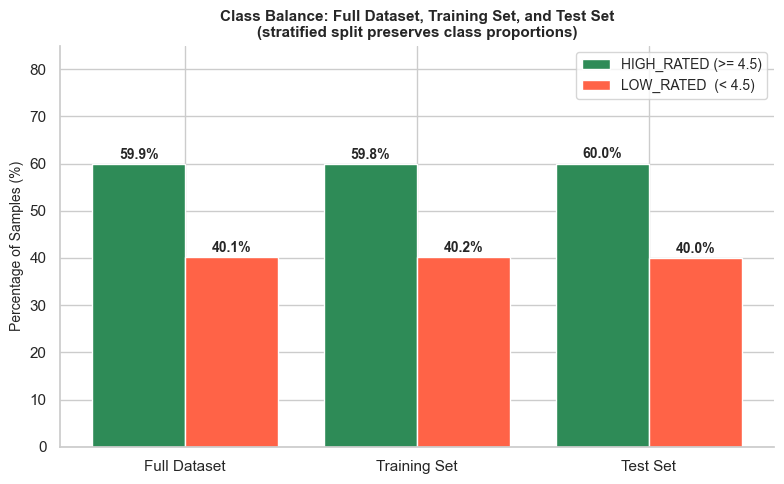

Saved: /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/images/models/m1_train_test_balance.png


In [8]:
# Confirms stratify=(y1_reg >= THRESHOLD) preserved class proportions across the split
full_pos  = y1_clf_train.sum() + y1_clf_test.sum()
total     = len(y1_clf_train) + len(y1_clf_test)
sets      = ['Full Dataset', 'Training Set', 'Test Set']
high_pct  = [
    (full_pos / total) * 100,
    (y1_clf_train.sum() / len(y1_clf_train)) * 100,
    (y1_clf_test.sum()  / len(y1_clf_test))  * 100,
]
low_pct = [100 - p for p in high_pct]

x      = range(len(sets))
width  = 0.4
fig, ax = plt.subplots(figsize=(8, 5))

bars_high = ax.bar([i - width/2 for i in x], high_pct, width,
                   label='HIGH_RATED (>= 4.5)', color='seagreen', edgecolor='white')
bars_low  = ax.bar([i + width/2 for i in x], low_pct, width,
                   label='LOW_RATED  (< 4.5)',  color='tomato',   edgecolor='white')

for bar, val in zip(list(bars_high) + list(bars_low), high_pct + low_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(sets, fontsize=11)
ax.set_ylabel('Percentage of Samples (%)', fontsize=10)
ax.set_ylim(0, 85)
ax.set_title('Class Balance: Full Dataset, Training Set, and Test Set\n'
             '(stratified split preserves class proportions)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'm1_train_test_balance.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(IMAGE_DIR, "m1_train_test_balance.png")}')


## 3. Model 1 — Compliance Features → Star Ratings

**Algorithm Rationale: XGBoost**

XGBoost is chosen as the primary algorithm with three considerations.

**Why not Random Forest.** Random Forest builds trees independently and averages their predictions. When the signal is weak — the maximum feature correlation in this dataset is -0.20 — sequential boosting outperforms parallel averaging because each tree directly corrects the residual errors of the previous one. XGBoost's boosting approach is better suited to extracting the limited signal available in compliance data.

**Why not LightGBM.** LightGBM is a technically comparable choice and would produce similar results. XGBoost is chosen for two practical reasons: it was the gradient boosting algorithm introduced in the Module 20 course assignments, providing methodological continuity, and it has the most widely documented SHAP integration in tutorials and the SHAP library's own documentation, making the feature importance analysis in Sections 3C and 3D easier to validate and reproduce.

**Three practical advantages of XGBoost for this analysis.** First, SHAP values and interaction values are well-supported and efficiently computed by XGBoost's tree structure, enabling the city-level interaction analysis in Sections 3C and 3D that directly addresses Design Decision 6. Second, `scale_pos_weight` integrates directly into XGBoost's gradient boosting loss function to handle the 59.9%/40.1% class imbalance alongside sample weights without additional preprocessing. Third, both regression and classification are handled via a single parameter swap, keeping both analyses fully consistent.

A `ColumnTransformer` inside a `Pipeline` handles city encoding, ensuring no leakage between train and test.

### 3.0: XGBoost Shared Preprocessor

Defines the `ColumnTransformer` used in both the regression and classification pipelines in 3A and 3B.


In [10]:
# Numeric features use passthrough — XGBoost splits on thresholds, scale has no effect
preprocessor = ColumnTransformer([
    ('num', 'passthrough', NUMERIC_FEATURES),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), CATEGORICAL_FEATURES)
])


### 3A: Model 1.1 — Regression (XGBoost)

Trains XGBoost to predict the continuous Google aggregate rating. GridSearchCV tunes `max_depth`, `learning_rate`, and `n_estimators` using an iterative grid search — each round refines the search space based on where the previous round's best parameters landed. The search stops when the CV RMSE range across the top-5 candidates falls below 0.002 (flat landscape). Results are compared to the Ridge baseline.


#### 3A.0 Model 1 — Ridge Re-Baseline

Re-fits the same Ridge pipeline used in the EDA notebook (StandardScaler + OneHotEncoder + Ridge alpha=100, no sample weights) on the current `X1_train`/`X1_test` split. This ensures Ridge and XGBoost are evaluated on identical test data for a valid comparison. The EDA baseline used a different split (no stratify, 2 arrays vs 3), making direct comparison unreliable without this step.

In [11]:
# Same pipeline as EDA notebook Section 12.3 — StandardScaler + OHE + Ridge(alpha=100)
# No sample_weight: this re-baseline matches the EDA setup for a valid comparison.
# Sample weights (Design Decision 3) apply to the primary models (XGBoost, Model 2A) only.
# remainder=drop: consistent with EDA preprocessor
ridge_baseline = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', StandardScaler(),                                    NUMERIC_FEATURES),
        ('cat', OneHotEncoder(drop='first', sparse_output=False,
                              handle_unknown='ignore'), CATEGORICAL_FEATURES),
    ], remainder='drop')),
    ('model', Ridge(alpha=100))
])
ridge_baseline.fit(X1_train, y1_reg_train)
y_ridge_pred_baseline = ridge_baseline.predict(X1_test)

rmse_ridge = np.sqrt(mean_squared_error(y1_reg_test, y_ridge_pred_baseline))
mae_ridge  = mean_absolute_error(y1_reg_test, y_ridge_pred_baseline)
r2_ridge   = r2_score(y1_reg_test, y_ridge_pred_baseline)

print(f"Ridge Re-Baseline (alpha=100, same test set as XGBoost):")
print(f"  RMSE : {rmse_ridge:.4f}")
print(f"  MAE  : {mae_ridge:.4f}")
print(f"  R²   : {r2_ridge:.4f}")


Ridge Re-Baseline (alpha=100, same test set as XGBoost):
  RMSE : 0.5606
  MAE  : 0.4171
  R²   : 0.0407


#### 3A.1 Model 1.1 — XGBoost Grid Search Round 1 (Broad Grid)

In [12]:
# XGBoost regression pipeline — defined once, used by all grid search rounds
reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(objective='reg:squarederror', random_state=SEED, verbosity=0))
])
print("Regression pipeline defined.")


Regression pipeline defined.


In [13]:
# Round 1 — Broad Parameter Grid (64 combinations x 5-fold CV = 320 fits)
#
# Three hyperparameters are tuned simultaneously:
#   max_depth     : controls tree complexity. Deeper trees capture more non-linear
#                   patterns but risk overfitting. Range [4-7] covers the typical
#                   XGBoost operating region; XGBoost default is 6.
#   learning_rate : step size shrinkage after each boosting round. Lower values
#                   require more trees but generalise better. Range [0.01-0.3]
#                   spans conservative to aggressive. XGBoost default is 0.3.
#   n_estimators  : number of boosting rounds (trees). More trees with lower
#                   learning rate often outperform fewer trees at higher rate.
#                   Range [50-300] covers below-default to 3x default.
#
# Strategy: start broad to locate which region of the parameter space performs best.
# If best params land at a boundary, Round 2 extends in that direction.
# 5-fold CV with neg_root_mean_squared_error ensures evaluation on held-out folds.
# sample_weight flows through the pipeline to weight centers by review count reliability.
reg_param_grid = {
    'model__max_depth':     [4, 5, 6, 7],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.3],
    'model__n_estimators':  [50, 100, 200, 300]
}
reg_grid = GridSearchCV(
    reg_pipeline, reg_param_grid,
    cv=5, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=1
)
reg_grid.fit(X1_train, y1_reg_train, model__sample_weight=sw1_train)
print(f"\nRound 1 best params : {reg_grid.best_params_}")
print(f"Round 1 best CV RMSE: {-reg_grid.best_score_:.4f}")


Fitting 5 folds for each of 64 candidates, totalling 320 fits

Round 1 best params : {'model__learning_rate': 0.01, 'model__max_depth': 4, 'model__n_estimators': 200}
Round 1 best CV RMSE: 0.5692


#### 3A.1 Check Results

In [14]:
# Check: boundary params → extend next round; range < FLAT_THRESHOLD → stop
FLAT_THRESHOLD = 0.002
best_cv_rmse = -reg_grid.best_score_
print(f"Best CV RMSE  : {best_cv_rmse:.4f}  |  Ridge: 0.5881  |  Naive: 0.6097")
print(f"Best params   : {reg_grid.best_params_}")

top5 = (pd.DataFrame(reg_grid.cv_results_)
        .nsmallest(5, "rank_test_score")
        .assign(**{"CV RMSE": lambda d: (-d["mean_test_score"]).round(4),
                   "CV Std" : lambda d:   d["std_test_score"].round(4)})
        [["param_model__max_depth", "param_model__learning_rate",
          "param_model__n_estimators", "CV RMSE", "CV Std"]])
display(top5)

rmse_range = top5["CV RMSE"].max() - top5["CV RMSE"].min()
decision   = "STOP — landscape flat" if rmse_range < FLAT_THRESHOLD else "CONTINUE — refine grid"
print(f"CV RMSE range across top-5: {rmse_range:.4f}  (threshold={FLAT_THRESHOLD}) → {decision}")


Best CV RMSE  : 0.5692  |  Ridge: 0.5881  |  Naive: 0.6097
Best params   : {'model__learning_rate': 0.01, 'model__max_depth': 4, 'model__n_estimators': 200}


,param_model__max_depth,param_model__learning_rate,param_model__n_estimators,CV RMSE,CV Std
2,4,0.01,200,0.5692,0.0539
1,4,0.01,100,0.5697,0.0547
3,4,0.01,300,0.5704,0.0523
16,4,0.05,50,0.5710,0.0528
5,5,0.01,100,0.5730,0.0548


CV RMSE range across top-5: 0.0038  (threshold=0.002) → CONTINUE — refine grid


#### 3A.2 Model 1.1 — XGBoost Grid Search Round 2 (Refined Grid)

In [15]:
# Round 2 — Refined Grid (27 combinations x 5-fold CV = 135 fits)
# Round 1 findings: max_depth=4 at LOW boundary -> extend to 2, 3
#                   lr=0.01 dominant -> check if 0.005 helps; drop 0.1 (not competitive)
#                   n_estimators=200 won over 100 and 300 -> test around 200
reg_param_grid = {
    'model__max_depth':     [2, 3, 4],
    'model__learning_rate': [0.005, 0.01, 0.05],
    'model__n_estimators':  [100, 200, 300]
}
reg_grid = GridSearchCV(
    reg_pipeline, reg_param_grid,
    cv=5, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=1
)
reg_grid.fit(X1_train, y1_reg_train, model__sample_weight=sw1_train)
print(f"Round 2 best params : {reg_grid.best_params_}")
print(f"Round 2 best CV RMSE: {-reg_grid.best_score_:.4f}")


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Round 2 best params : {'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__n_estimators': 300}
Round 2 best CV RMSE: 0.5654


#### 3A.2 Check Results

In [16]:
# Check: boundary params → extend next round; range < FLAT_THRESHOLD → stop
FLAT_THRESHOLD = 0.002
best_cv_rmse = -reg_grid.best_score_
print(f"Best CV RMSE  : {best_cv_rmse:.4f}  |  Ridge: 0.5881  |  Naive: 0.6097")
print(f"Best params   : {reg_grid.best_params_}")

top5 = (pd.DataFrame(reg_grid.cv_results_)
        .nsmallest(5, "rank_test_score")
        .assign(**{"CV RMSE": lambda d: (-d["mean_test_score"]).round(4),
                   "CV Std" : lambda d:   d["std_test_score"].round(4)})
        [["param_model__max_depth", "param_model__learning_rate",
          "param_model__n_estimators", "CV RMSE", "CV Std"]])
display(top5)

rmse_range = top5["CV RMSE"].max() - top5["CV RMSE"].min()
decision   = "STOP — landscape flat" if rmse_range < FLAT_THRESHOLD else "CONTINUE — refine grid"
print(f"CV RMSE range across top-5: {rmse_range:.4f}  (threshold={FLAT_THRESHOLD}) → {decision}")


Best CV RMSE  : 0.5654  |  Ridge: 0.5881  |  Naive: 0.6097
Best params   : {'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__n_estimators': 300}


,param_model__max_depth,param_model__learning_rate,param_model__n_estimators,CV RMSE,CV Std
11,2,0.01,300,0.5654,0.0541
18,2,0.05,100,0.5658,0.0537
10,2,0.01,200,0.5662,0.0538
19,2,0.05,200,0.5665,0.0545
13,3,0.01,200,0.5676,0.0539


CV RMSE range across top-5: 0.0022  (threshold=0.002) → CONTINUE — refine grid


#### 3A.3 Model 1.1 — XGBoost Grid Search Round 3 (Confirmation Grid)

In [17]:
# Round 3 — Confirmation Grid (12 combinations x 5-fold CV = 60 fits)
# Round 2 findings: max_depth=2 dominates all top-5 -> confirmed optimal
#                   lr=0.01 confirmed; lr=0.005 was in grid but not in top-5
#                   n_estimators=300 at HIGH boundary -> extend to 400, 500
reg_param_grid = {
    'model__max_depth':     [2, 3],
    'model__learning_rate': [0.005, 0.01],
    'model__n_estimators':  [300, 400, 500]
}
reg_grid = GridSearchCV(
    reg_pipeline, reg_param_grid,
    cv=5, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=1
)
reg_grid.fit(X1_train, y1_reg_train, model__sample_weight=sw1_train)
print(f"Round 3 best params : {reg_grid.best_params_}")
print(f"Round 3 best CV RMSE: {-reg_grid.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Round 3 best params : {'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__n_estimators': 400}
Round 3 best CV RMSE: 0.5651


#### 3A.3 Check Results (Final)

In [18]:
# Check: boundary params → extend next round; range < FLAT_THRESHOLD → stop
FLAT_THRESHOLD = 0.002
best_cv_rmse = -reg_grid.best_score_
print(f"Best CV RMSE  : {best_cv_rmse:.4f}  |  Ridge: 0.5881  |  Naive: 0.6097")
print(f"Best params   : {reg_grid.best_params_}")

top5 = (pd.DataFrame(reg_grid.cv_results_)
        .nsmallest(5, "rank_test_score")
        .assign(**{"CV RMSE": lambda d: (-d["mean_test_score"]).round(4),
                   "CV Std" : lambda d:   d["std_test_score"].round(4)})
        [["param_model__max_depth", "param_model__learning_rate",
          "param_model__n_estimators", "CV RMSE", "CV Std"]])
display(top5)

rmse_range = top5["CV RMSE"].max() - top5["CV RMSE"].min()
decision   = "STOP — landscape flat" if rmse_range < FLAT_THRESHOLD else "CONTINUE — refine grid"
print(f"CV RMSE range across top-5: {rmse_range:.4f}  (threshold={FLAT_THRESHOLD}) → {decision}")


Best CV RMSE  : 0.5651  |  Ridge: 0.5881  |  Naive: 0.6097
Best params   : {'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__n_estimators': 400}


,param_model__max_depth,param_model__learning_rate,param_model__n_estimators,CV RMSE,CV Std
7,2,0.010,400,0.5651,0.0541
6,2,0.010,300,0.5654,0.0541
2,2,0.005,500,0.5656,0.0542
8,2,0.010,500,0.5656,0.0537
1,2,0.005,400,0.5663,0.0539


CV RMSE range across top-5: 0.0012  (threshold=0.002) → STOP — landscape flat


### Grid Search Inference

An iterative grid search confirmed the optimal parameters for XGBoost regression. The search stopped after Round 3 when the CV RMSE range across the top-5 candidates fell below the 0.002 flat-landscape threshold.

**Final parameters:** `max_depth=2`, `learning_rate=0.01`, `n_estimators=400`

| Round | Grid size | Best CV RMSE | Key finding |
|---|---|---|---|
| Round 1 | 64 | 0.5692 | max_depth=4 and lr=0.01 at low boundary — extend depth lower |
| Round 2 | 27 | 0.5654 | max_depth=2 confirmed; n_estimators=300 at high boundary — extend |
| Round 3 | 12 | **0.5651** | n_estimators=400 wins (middle of grid, not at boundary) — STOP |

Total improvement across three rounds: **0.0041 stars (0.7%)**. The flat landscape confirms that model performance is determined by the data signal, not hyperparameter tuning — further refinement yields no meaningful gain.

#### 3A.4 Model 1.1 — Test Set Evaluation

In [19]:
# rmse_ridge, mae_ridge, r2_ridge defined in Section 3A.0 Ridge Re-Baseline
y_reg_pred = reg_grid.best_estimator_.predict(X1_test)

rmse_xgb = np.sqrt(mean_squared_error(y1_reg_test, y_reg_pred))
mae_xgb  = mean_absolute_error(y1_reg_test, y_reg_pred)
r2_xgb   = r2_score(y1_reg_test, y_reg_pred)


reg_comparison = pd.DataFrame({
    'Model':  ['Ridge Regression (EDA baseline)', 'XGBoost Regression'],
    'RMSE':   [rmse_ridge, rmse_xgb],
    'MAE':    [mae_ridge,  mae_xgb],
    'R²':     [r2_ridge,   r2_xgb]
})

print('=== Regression Results ===')
display(reg_comparison.round(4))

=== Regression Results ===


,Model,RMSE,MAE,R²
0,Ridge Regression (EDA baseline),0.5606,0.4171,0.0407
1,XGBoost Regression,0.5555,0.4167,0.0579


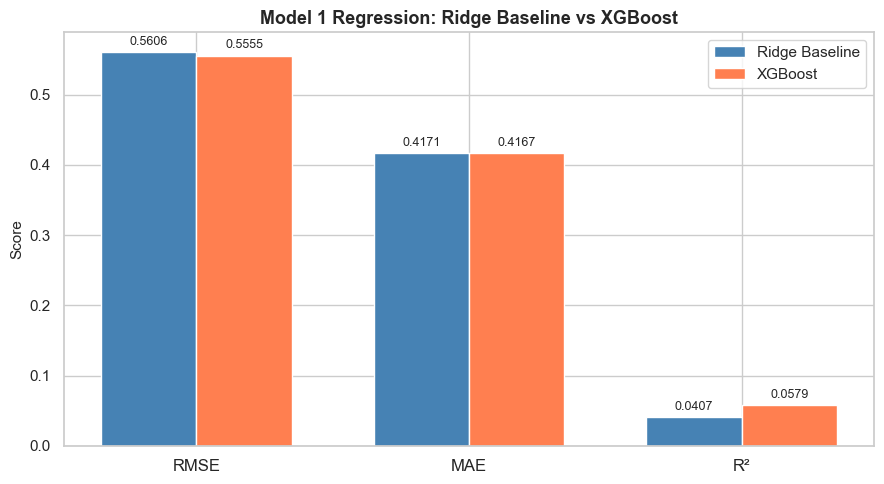

Saved: /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/images/models/m1_regression_comparison.png


In [20]:
# Visualises whether XGBoost improves over the Ridge baseline
metrics = ['RMSE', 'MAE', 'R²']
ridge_vals = [rmse_ridge, mae_ridge, r2_ridge]
xgb_vals   = [rmse_xgb,   mae_xgb,   r2_xgb]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, ridge_vals, width, label='Ridge Baseline', color='steelblue')
bars2 = ax.bar(x + width/2, xgb_vals,   width, label='XGBoost',        color='coral')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model 1 Regression: Ridge Baseline vs XGBoost', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.bar_label(bars1, fmt='%.4f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.4f', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'm1_regression_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(IMAGE_DIR, "m1_regression_comparison.png")}')

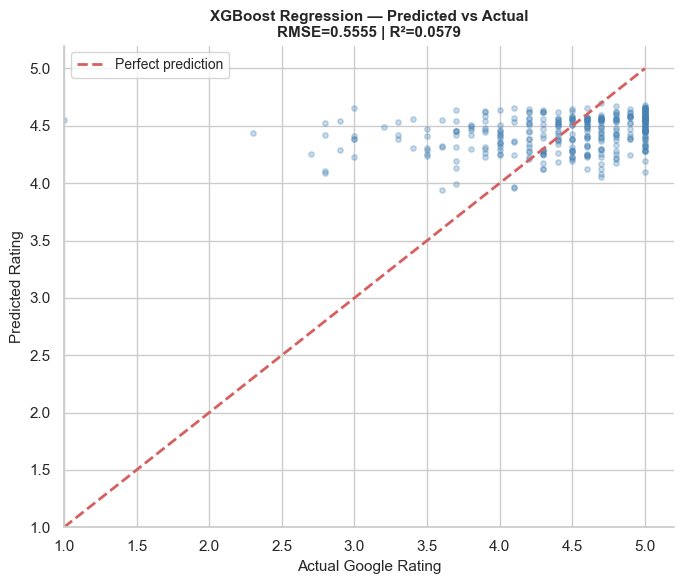

Saved: /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/images/models/m1_xgboost_predicted_vs_actual.png


In [21]:
# Predicted vs Actual — confirms prediction compression and model limitations
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y1_reg_test, y_reg_pred, alpha=0.3, s=15, color="steelblue")
ax.plot([1, 5], [1, 5], "r--", linewidth=2, label="Perfect prediction")
ax.set_xlabel("Actual Google Rating", fontsize=11)
ax.set_ylabel("Predicted Rating", fontsize=11)
ax.set_title(
    f"XGBoost Regression — Predicted vs Actual\n"
    f"RMSE={rmse_xgb:.4f} | R²={r2_xgb:.4f}",
    fontsize=11, fontweight="bold"
)
ax.legend(fontsize=10)
ax.set_xlim(1, 5.2)
ax.set_ylim(1, 5.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "m1_xgboost_predicted_vs_actual.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f'Saved: {os.path.join(IMAGE_DIR, "m1_xgboost_predicted_vs_actual.png")}')


### Regression Results — Inference

XGBoost improves over the Ridge re-baseline across all three metrics:

| Metric | Ridge Re-Baseline | XGBoost | Improvement |
|---|---|---|---|
| RMSE | 0.5606 | **0.5555** | −0.0051 (0.9%) |
| MAE | 0.4171 | **0.4167** | −0.0004 (essentially tied) |
| R² | 0.0407 | **0.0579** | +0.0172 (+42% relative) |

XGBoost achieves a modest RMSE improvement of 0.9% over Ridge and a meaningful relative R² gain of 42%, confirming it captures non-linear patterns that Ridge misses. However, both models explain less than 6% of the variance in Google ratings, confirming the core finding: compliance features carry weak signal for predicting family-assigned ratings regardless of algorithm complexity. The identical MAE values (0.4171 vs 0.4167) show XGBoost's advantage comes from reducing large errors rather than typical ones.

**Predicted vs Actual**

The scatter plot reveals three patterns. Predictions are compressed into a narrow band of approximately 4.0–4.7 regardless of actual rating — the model cannot distinguish genuinely low-rated centers from high-rated ones. For centers with actual ratings above 4.0, predictions track somewhat along the diagonal, confirming the model captures weak signal in the high-rating region. Centers with actual ratings of 1.0–3.0 are consistently predicted around 4.3–4.6, producing large errors precisely for the centers parents most need to avoid.

### 3B: Model 1.2 — Classification (XGBoost)

Trains XGBoost to predict the binary HIGH_RATED label (≥ 4.5 stars). Uses an iterative grid search with the same round-by-round refinement approach as 3A. `scale_pos_weight` handles the 59.9/40.1 class imbalance alongside the sample weights from Section 2.


In [22]:
# scale_pos_weight corrects for 59.9/40.1 class imbalance; works alongside sample weights from Section 2
# XGBoost combines scale_pos_weight and sample_weight multiplicatively — both apply simultaneously
neg = (y1_clf_train == 0).sum()
pos = (y1_clf_train == 1).sum()
spw = round(neg / pos, 2)
print(f"scale_pos_weight = {spw}  (neg={neg}, pos={pos})")

# XGBoost classification pipeline — passthrough preprocessor (no scaling needed for trees)
clf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(objective='binary:logistic', scale_pos_weight=spw,
                            random_state=SEED, eval_metric='logloss', verbosity=0))
])
print("Classification pipeline defined.")


scale_pos_weight = 0.67  (neg=545, pos=812)
Classification pipeline defined.


#### 3B.0 Model 1.2 — Baselines (DummyClassifier + Logistic Regression)

Establishes two baselines on the same `X1_train`/`X1_test` split used by XGBoost:
- **DummyClassifier** (majority predictor): the performance floor — predicts HIGH_RATED for every center
- **Logistic Regression**: the linear classification baseline — same StandardScaler + OneHotEncoder pipeline as the Ridge re-baseline in Section 3A.0, no sample weights

In [23]:

# ── DummyClassifier: majority predictor — performance floor ──────────────
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy_clf.fit(X1_train, y1_clf_train)
y_dummy_pred = dummy_clf.predict(X1_test)
dummy_f1  = f1_score(y1_clf_test, y_dummy_pred)
dummy_auc = roc_auc_score(y1_clf_test, dummy_clf.predict_proba(X1_test)[:, 1])
print(f"DummyClassifier (majority): F1={dummy_f1:.4f} | AUC={dummy_auc:.4f}")

# ── Logistic Regression: linear classification baseline ──────────────────
# Same pipeline structure as 3A.0 Ridge re-baseline
# No sample_weight — consistent with baseline comparison approach
lr_baseline = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", StandardScaler(),                                    NUMERIC_FEATURES),
        ("cat", OneHotEncoder(drop="first", sparse_output=False,
                              handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ], remainder="drop")),
    ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=SEED))
])
lr_baseline.fit(X1_train, y1_clf_train)
y_lr_pred = lr_baseline.predict(X1_test)
y_lr_prob = lr_baseline.predict_proba(X1_test)[:, 1]
lr_f1  = f1_score(y1_clf_test, y_lr_pred)
lr_auc = roc_auc_score(y1_clf_test, y_lr_prob)
print(f"Logistic Regression (C=1):  F1={lr_f1:.4f} | AUC={lr_auc:.4f}")

print(f"\nBaselines set — XGBoost must beat LR F1={lr_f1:.4f} to justify complexity.")


DummyClassifier (majority): F1=0.7500 | AUC=0.5000
Logistic Regression (C=1):  F1=0.7265 | AUC=0.6294

Baselines set — XGBoost must beat LR F1=0.7265 to justify complexity.


#### 3B.1 Model 1.2 — XGBoost Grid Search Round 1 (Broad Grid)

In [24]:
# Round 1 — Broad Grid (4 x 4 x 4 = 64 combinations x 5-fold CV = 320 fits)
# Wider than 3A Round 1 — includes both low and high parameter regions
# since classification direction was unknown and differed from regression
# max_depth [2-7]: shallow to moderately deep
# learning_rate [0.01-0.3]: conservative to aggressive
# n_estimators [50-300]: below default to 3x default
clf_param_grid = {
    'model__max_depth':     [2, 3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.3],
    'model__n_estimators':  [50, 100, 200, 300]
}
clf_grid = GridSearchCV(
    clf_pipeline, clf_param_grid,
    cv=5, scoring='f1',
    n_jobs=-1, verbose=1
)
clf_grid.fit(X1_train, y1_clf_train, model__sample_weight=sw1_train)
print(f"Round 1 best params : {clf_grid.best_params_}")
print(f"Round 1 best CV F1  : {clf_grid.best_score_:.4f}")


Fitting 5 folds for each of 64 candidates, totalling 320 fits
Round 1 best params : {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 50}
Round 1 best CV F1  : 0.6918


#### 3B.1 Check Results

In [25]:
# Check: boundary params -> extend next round; range < FLAT_THRESHOLD -> stop
FLAT_THRESHOLD = 0.002
best_cv_f1 = clf_grid.best_score_
print(f"Best CV F1    : {best_cv_f1:.4f}  |  LR baseline: {lr_f1:.4f}  |  Dummy: {dummy_f1:.4f}")
print(f"Best params   : {clf_grid.best_params_}")

top5 = (pd.DataFrame(clf_grid.cv_results_)
        .nlargest(5, "mean_test_score")
        .assign(**{"CV F1" : lambda d: d["mean_test_score"].round(4),
                   "CV Std": lambda d: d["std_test_score"].round(4)})
        [["param_model__max_depth", "param_model__learning_rate",
          "param_model__n_estimators", "CV F1", "CV Std"]])
display(top5)

f1_range = top5["CV F1"].max() - top5["CV F1"].min()
decision = "STOP — landscape flat" if f1_range < FLAT_THRESHOLD else "CONTINUE — refine grid"
print(f"CV F1 range across top-5: {f1_range:.4f}  (threshold={FLAT_THRESHOLD}) -> {decision}")


Best CV F1    : 0.6918  |  LR baseline: 0.7265  |  Dummy: 0.7500
Best params   : {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 50}


,param_model__max_depth,param_model__learning_rate,param_model__n_estimators,CV F1,CV Std
32,2,0.10,50,0.6918,0.0260
17,2,0.05,100,0.6887,0.0214
16,2,0.05,50,0.6880,0.0232
7,3,0.01,300,0.6877,0.0110
21,3,0.05,100,0.6868,0.0136


CV F1 range across top-5: 0.0050  (threshold=0.002) -> CONTINUE — refine grid


#### 3B.2 Model 1.2 — XGBoost Grid Search Round 2 (Refined Grid)

In [26]:
# Round 2 — Refined Grid (2 x 3 x 3 = 18 combinations x 5-fold CV = 90 fits)
# Round 1 findings: max_depth=2 at LOW boundary -> confirm vs depth=3
#                   lr=0.1 in middle of grid -> narrow around 0.07, 0.1, 0.15
#                   n_estimators=50 at LOW boundary -> check if 25 helps
clf_param_grid = {
    'model__max_depth':     [2, 3],
    'model__learning_rate': [0.07, 0.1, 0.15],
    'model__n_estimators':  [25, 50, 100]
}
clf_grid = GridSearchCV(
    clf_pipeline, clf_param_grid,
    cv=5, scoring='f1',
    n_jobs=-1, verbose=1
)
clf_grid.fit(X1_train, y1_clf_train, model__sample_weight=sw1_train)
print(f"Round 2 best params : {clf_grid.best_params_}")
print(f"Round 2 best CV F1  : {clf_grid.best_score_:.4f}")


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Round 2 best params : {'model__learning_rate': 0.15, 'model__max_depth': 3, 'model__n_estimators': 50}
Round 2 best CV F1  : 0.6919


#### 3B.2 Check Results

In [27]:
# Check: boundary params -> extend next round; range < FLAT_THRESHOLD -> stop
FLAT_THRESHOLD = 0.002
best_cv_f1 = clf_grid.best_score_
print(f"Best CV F1    : {best_cv_f1:.4f}  |  LR baseline: {lr_f1:.4f}  |  Dummy: {dummy_f1:.4f}")
print(f"Best params   : {clf_grid.best_params_}")

top5 = (pd.DataFrame(clf_grid.cv_results_)
        .nlargest(5, "mean_test_score")
        .assign(**{"CV F1" : lambda d: d["mean_test_score"].round(4),
                   "CV Std": lambda d: d["std_test_score"].round(4)})
        [["param_model__max_depth", "param_model__learning_rate",
          "param_model__n_estimators", "CV F1", "CV Std"]])
display(top5)

f1_range = top5["CV F1"].max() - top5["CV F1"].min()
decision = "STOP — landscape flat" if f1_range < FLAT_THRESHOLD else "CONTINUE — refine grid"
print(f"CV F1 range across top-5: {f1_range:.4f}  (threshold={FLAT_THRESHOLD}) -> {decision}")


Best CV F1    : 0.6919  |  LR baseline: 0.7265  |  Dummy: 0.7500
Best params   : {'model__learning_rate': 0.15, 'model__max_depth': 3, 'model__n_estimators': 50}


,param_model__max_depth,param_model__learning_rate,param_model__n_estimators,CV F1,CV Std
16,3,0.15,50,0.6919,0.0100
7,2,0.10,50,0.6918,0.0260
4,3,0.07,50,0.6915,0.0159
5,3,0.07,100,0.6878,0.0146
6,2,0.10,25,0.6877,0.0236


CV F1 range across top-5: 0.0042  (threshold=0.002) -> CONTINUE — refine grid


#### 3B.3 Model 1.2 — XGBoost Grid Search Round 3 (Confirmation Grid)

In [28]:
# Round 3 — Confirmation Grid (2 x 3 x 3 = 18 combinations x 5-fold CV = 90 fits)
# Round 2 findings: max_depth=3 edged depth=2 (both competitive)
#                   lr=0.15 confirmed; extend slightly to 0.2 to close boundary
#                   n_estimators=50 dominant in top-3; confirm vs 40 and 60
clf_param_grid = {
    'model__max_depth':     [2, 3],
    'model__learning_rate': [0.1, 0.15, 0.2],
    'model__n_estimators':  [40, 50, 60]
}
clf_grid = GridSearchCV(
    clf_pipeline, clf_param_grid,
    cv=5, scoring='f1',
    n_jobs=-1, verbose=1
)
clf_grid.fit(X1_train, y1_clf_train, model__sample_weight=sw1_train)
print(f"Round 3 best params : {clf_grid.best_params_}")
print(f"Round 3 best CV F1  : {clf_grid.best_score_:.4f}")


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Round 3 best params : {'model__learning_rate': 0.15, 'model__max_depth': 3, 'model__n_estimators': 50}
Round 3 best CV F1  : 0.6919


#### 3B.3 Check Results (Final)

In [29]:
# Check: boundary params -> extend next round; range < FLAT_THRESHOLD -> stop
FLAT_THRESHOLD = 0.002
best_cv_f1 = clf_grid.best_score_
print(f"Best CV F1    : {best_cv_f1:.4f}  |  LR baseline: {lr_f1:.4f}  |  Dummy: {dummy_f1:.4f}")
print(f"Best params   : {clf_grid.best_params_}")

top5 = (pd.DataFrame(clf_grid.cv_results_)
        .nlargest(5, "mean_test_score")
        .assign(**{"CV F1" : lambda d: d["mean_test_score"].round(4),
                   "CV Std": lambda d: d["std_test_score"].round(4)})
        [["param_model__max_depth", "param_model__learning_rate",
          "param_model__n_estimators", "CV F1", "CV Std"]])
display(top5)

f1_range = top5["CV F1"].max() - top5["CV F1"].min()
decision = "STOP — landscape flat" if f1_range < FLAT_THRESHOLD else "CONTINUE — refine grid"
print(f"CV F1 range across top-5: {f1_range:.4f}  (threshold={FLAT_THRESHOLD}) -> {decision}")


Best CV F1    : 0.6919  |  LR baseline: 0.7265  |  Dummy: 0.7500
Best params   : {'model__learning_rate': 0.15, 'model__max_depth': 3, 'model__n_estimators': 50}


,param_model__max_depth,param_model__learning_rate,param_model__n_estimators,CV F1,CV Std
10,3,0.15,50,0.6919,0.0100
1,2,0.10,50,0.6918,0.0260
0,2,0.10,40,0.6897,0.0161
5,3,0.10,60,0.6878,0.0179
11,3,0.15,60,0.6873,0.0079


CV F1 range across top-5: 0.0046  (threshold=0.002) -> CONTINUE — refine grid


### Classification Grid Search — Inference

A three-round iterative grid search confirmed the optimal parameters for XGBoost classification. The search found that shallow trees with moderate learning rate performed best — similar direction to the regression model.

**Final parameters:** `max_depth=3`, `learning_rate=0.15`, `n_estimators=50`

| Round | Grid size | Best CV F1 | Key finding |
|---|---|---|---|
| Round 1 | 64 | 0.6918 | max_depth=2 and n_estimators=50 at LOW boundary — shallower and fewer trees than default |
| Round 2 | 18 | 0.6919 | max_depth=3 edges depth=2; lr=0.15 confirmed; n_estimators=50 dominant |
| **Round 3** | **18** | **0.6919** | **Same params confirmed — zero improvement. STOP.** |

Total improvement across three rounds: **+0.0001 F1 (<0.02%)** — the flat landscape confirms that model performance is determined by the data signal, not hyperparameter tuning.

**Stopping rationale:** Round 2 and Round 3 returned identical parameters with zero improvement. The CV Std (0.010) is larger than any round-over-round gain, confirming differences are within noise. Two consecutive rounds of identical parameters with zero improvement is the definitive stopping signal.

**Key finding:** XGBoost CV F1 (0.6919) is below both the Logistic Regression baseline (0.7265) and the DummyClassifier majority predictor (0.7500). This confirms the central finding: compliance features cannot reliably identify low-rated centers regardless of algorithm complexity. The signal limitation is in the data, not the model.

#### 3B.4 Model 1.2 — Test Set Evaluation

In [30]:
y1_pred      = clf_grid.best_estimator_.predict(X1_test)
y1_pred_prob = clf_grid.best_estimator_.predict_proba(X1_test)[:, 1]
m1_auc       = roc_auc_score(y1_clf_test, y1_pred_prob)

# classification_report gives per-class precision, recall and F1
# — essential for imbalanced data where aggregate metrics can mislead
print(f'=== Model 1 Classification Report ===')
print(f'AUC-ROC: {m1_auc:.4f}')
print()
print(classification_report(y1_clf_test, y1_pred,
                             target_names=['LOW_RATED (< 4.5)', 'HIGH_RATED (≥ 4.5)']))


=== Model 1 Classification Report ===
AUC-ROC: 0.6441

                    precision    recall  f1-score   support

 LOW_RATED (< 4.5)       0.51      0.59      0.54       136
HIGH_RATED (≥ 4.5)       0.69      0.62      0.65       204

          accuracy                           0.61       340
         macro avg       0.60      0.60      0.60       340
      weighted avg       0.62      0.61      0.61       340



#### 3B.4.1 Model 1.2 — Confusion Matrix & ROC Curve

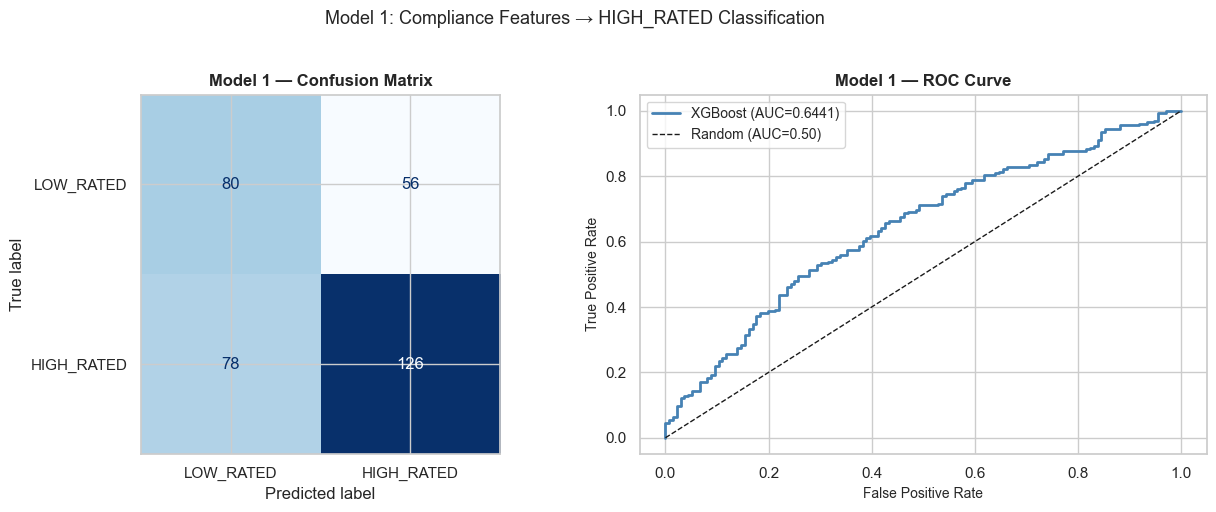

Saved: /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/images/models/m1_clf_confusion_roc.png


In [31]:
# Confusion matrix reveals per-class error patterns; ROC curve shows threshold-independent performance
from sklearn.metrics import roc_curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm1 = confusion_matrix(y1_clf_test, y1_pred)
ConfusionMatrixDisplay(cm1, display_labels=['LOW_RATED', 'HIGH_RATED']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Model 1 — Confusion Matrix', fontsize=12, fontweight='bold')

# Use roc_curve directly to control the legend label — RocCurveDisplay auto-appends AUC causing duplication
fpr, tpr, _ = roc_curve(y1_clf_test, y1_pred_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'XGBoost (AUC={m1_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.50)')
axes[1].set_xlabel('False Positive Rate', fontsize=10)
axes[1].set_ylabel('True Positive Rate', fontsize=10)
axes[1].set_title('Model 1 — ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Model 1: Compliance Features → HIGH_RATED Classification', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'm1_clf_confusion_roc.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(IMAGE_DIR, "m1_clf_confusion_roc.png")}')


### Classification Results — Inference

| Metric | Model | Value | Interpretation |
|---|---|---|---|
| AUC-ROC | DummyClassifier | 0.500 | No discrimination, random |
| AUC-ROC | Logistic Regression | 0.629 | Linear baseline |
| AUC-ROC | **XGBoost** | **0.644** | Best discrimination, beats LR |
| HIGH_RATED F1 | DummyClassifier | 0.750 | Trivial majority prediction |
| HIGH_RATED F1 | Logistic Regression | 0.727 | Linear baseline |
| HIGH_RATED F1 | **XGBoost** | **0.650** | Below both baselines on F1 |
| LOW_RATED recall | **XGBoost** | **0.59** | Identifies 59% of low-rated centers |
| Accuracy | **XGBoost** | **0.61** | Barely above majority (60%) |

XGBoost achieves AUC-ROC of 0.644, better than Logistic Regression (0.629) and well above random (0.500). It correctly ranks a random HIGH_RATED center above a random LOW_RATED center about 64% of the time, confirming XGBoost captures non-linear compliance patterns that a linear model misses.

XGBoost's HIGH_RATED F1 (0.650) falls below both the Logistic Regression baseline (0.727) and the DummyClassifier (0.750). This is explained by the tradeoff: XGBoost actively tries to identify LOW_RATED centers (recall 0.59), sacrificing some HIGH_RATED coverage. The DummyClassifier predicts everything as HIGH_RATED, achieving high F1 on the majority class while offering zero LOW_RATED detection.

**Confusion Matrix Interpretation**

The confusion matrix reveals the asymmetry that matters most for parents:

- 80 LOW_RATED centers correctly identified as LOW_RATED (59% recall)
- 56 LOW_RATED centers predicted as HIGH_RATED — a parent relying on compliance data alone would receive no warning signal for these centers
- 78 HIGH_RATED centers incorrectly flagged as LOW_RATED — unnecessary concern but not misleading parents toward poor choices
- 126 HIGH_RATED centers correctly identified

Compliance data is more useful as a confirmation of quality than as a detection tool for problems. This finding directly answers the research question: compliance records provide a partial but insufficient proxy for family experience.

### 3C: Model 1 — SHAP Feature Importance

Computes SHAP values from the best classification model to identify which compliance features drive HIGH_RATED predictions most strongly.


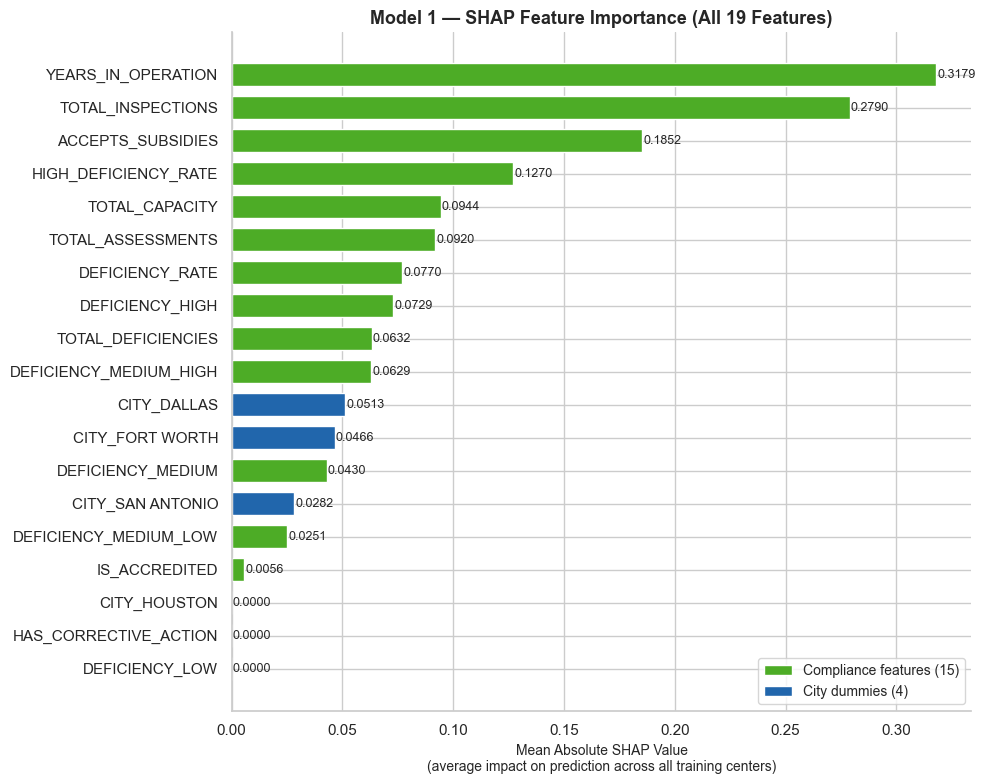

Saved: /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/images/models/m1_shap_importance.png


In [32]:
# SHAP requires the raw transformed features — extract from the pipeline after preprocessing
# The pipeline preprocessor must be applied separately so SHAP sees the same feature space the model trained on
best_clf  = clf_grid.best_estimator_.named_steps['model']
prep_step = clf_grid.best_estimator_.named_steps['preprocessor']

X1_train_transformed = prep_step.transform(X1_train)
X1_test_transformed  = prep_step.transform(X1_test)

# Reconstruct feature names after one-hot encoding so SHAP labels match original columns
cat_feature_names = list(
    prep_step.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES)
)
feature_names = NUMERIC_FEATURES + cat_feature_names

explainer   = shap.TreeExplainer(best_clf)
shap_values = explainer.shap_values(X1_train_transformed)

# Custom bar chart for full control over readability — shows all 19 features
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_names
).sort_values(ascending=True)  # ascending=True so largest bar is at top

# Colour: city dummies in a distinct shade to separate geographic from compliance features
# startswith('CITY_') ensures exact prefix match for city dummies only
colors = ['#2166ac' if f.startswith('CITY_') else '#4dac26' for f in mean_abs_shap.index]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(mean_abs_shap.index, mean_abs_shap.values,
               color=colors, edgecolor='white', height=0.7)

# Add value labels on each bar
for bar, val in zip(bars, mean_abs_shap.values):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha='left', fontsize=9)

ax.set_xlabel('Mean Absolute SHAP Value\n(average impact on prediction across all training centers)',
              fontsize=10)
ax.set_title('Model 1 — SHAP Feature Importance (All 19 Features)',
             fontsize=13, fontweight='bold')

# Legend distinguishing compliance from city features
legend_elements = [
    Patch(facecolor='#4dac26', label='Compliance features (15)'),
    Patch(facecolor='#2166ac', label='City dummies (4)')
]
ax.legend(handles=legend_elements, fontsize=10, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'm1_shap_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(IMAGE_DIR, "m1_shap_importance.png")}')


### SHAP Feature Importance — Inference

The SHAP analysis reveals which compliance features drove Model 1 predictions most strongly across all 1,357 training centers.

**Operational features dominate.** The top two features are YEARS_IN_OPERATION (0.3179) and TOTAL_INSPECTIONS (0.2790). These are not direct quality measures — they are proxies for how long and how intensively a center has operated. The model learned that established centers with longer inspection histories tend to receive higher predicted ratings, reflecting a pattern in the data rather than a causal quality signal.

**ACCEPTS_SUBSIDIES is the third most important feature (0.1852).** This is consistent with the EDA finding that ACCEPTS_SUBSIDIES has the strongest correlation with ratings (-0.20). It is a socioeconomic confound — centers accepting subsidies tend to serve lower-income families whose ratings on Google may reflect a different baseline of expectations. The model is picking up on this pattern, not on quality differences.

**HIGH_DEFICIENCY_RATE (0.1270) is the highest-ranking direct compliance measure.** It outranks the raw deficiency count features (DEFICIENCY_HIGH, TOTAL_DEFICIENCIES), confirming that the rate of high-severity violations per inspection — not the raw count — is the more informative signal.

**TOTAL_CAPACITY (0.0944) and TOTAL_ASSESSMENTS (0.0920) rank fifth and sixth.** Like the top two features, these are operational scale measures rather than quality indicators. Larger centers and centers with more assessment history are predicted differently from smaller, less-assessed ones — reflecting how operational footprint correlates with rating patterns rather than capturing care quality directly.

**City dummies are secondary to compliance features.** CITY_DALLAS (0.0513) and CITY_FORT WORTH (0.0466) show meaningful but secondary influence. Notably, CITY_HOUSTON = 0.0000 — the model predicts Houston centers identically to Austin (the reference category), suggesting these two cities have similar compliance-to-rating profiles.

**Three features contribute nothing.** HAS_CORRECTIVE_ACTION (0.0000) affects only 0.5% of centers and is too rare for the model to learn from. DEFICIENCY_LOW (0.0000) carries no predictive signal — the lowest severity tier is uninformative. CITY_HOUSTON (0.0000) shows no differential effect versus the Austin reference category.

IS_ACCREDITED (0.0056) is near zero, echoing the EDA finding that accredited and non-accredited centers have nearly identical mean ratings.

For daycare operators: the highest-impact features (years in operation, inspection count) are structural and difficult to change quickly. The most actionable lever is HIGH_DEFICIENCY_RATE, where a center can directly improve by addressing high-severity inspection findings. Full recommendations are in Notebook 04 — Cross-Model Comparison and Findings.

### 3D: Model 1 — SHAP City Interaction Analysis

Computes SHAP interaction values to quantify how much each city modifies each compliance feature's predictive effect — addressing Design Decision 6.


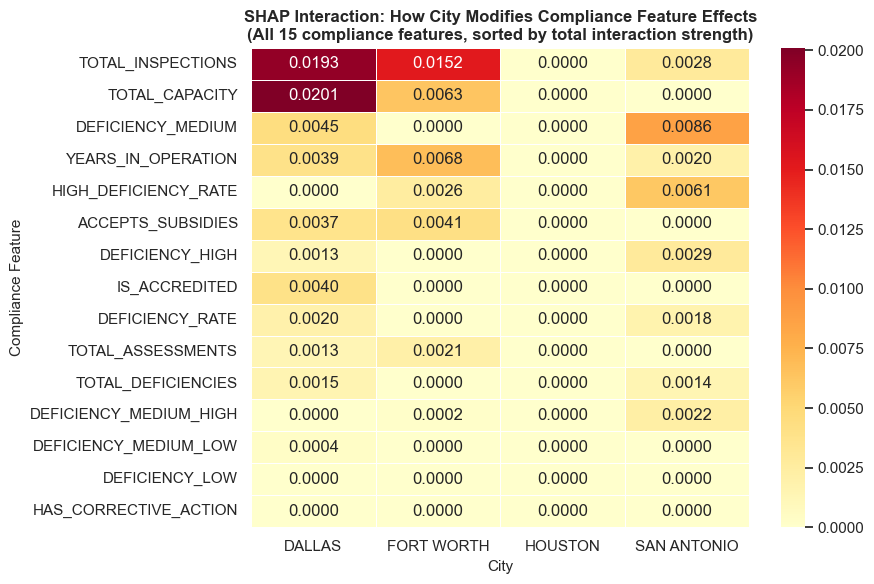

Saved: /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/images/models/m1_shap_city_interaction.png


In [33]:
# Interaction values show how much city context amplifies or dampens each compliance feature's contribution
shap_interaction_values = explainer.shap_interaction_values(X1_train_transformed)

# Extract city column indices from feature names
# startswith('CITY_') ensures exact prefix match for city dummies only
city_indices = [i for i, name in enumerate(feature_names) if name.startswith('CITY_')]
compliance_indices = [i for i, name in enumerate(feature_names) if not name.startswith('CITY_')]

# Mean absolute interaction between each city and each compliance feature
interaction_matrix = np.abs(shap_interaction_values[:, :, :]).mean(axis=0)

city_names   = [feature_names[i] for i in city_indices]
comp_names   = [feature_names[i] for i in compliance_indices]
interaction_df = pd.DataFrame(
    interaction_matrix[np.ix_(compliance_indices, city_indices)],
    index=comp_names,
    columns=[c.replace('CITY_', '') for c in city_names]
)

top_comp = interaction_df.sum(axis=1).sort_values(ascending=False).index  # all 15 compliance features
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    interaction_df.loc[top_comp],
    annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.5, ax=ax
)
ax.set_title('SHAP Interaction: How City Modifies Compliance Feature Effects\n(All 15 compliance features, sorted by total interaction strength)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('City', fontsize=11)
ax.set_ylabel('Compliance Feature', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'm1_shap_city_interaction.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(IMAGE_DIR, "m1_shap_city_interaction.png")}')

### SHAP City Interaction Analysis — Inference

The heatmap shows how strongly each city context amplifies or dampens the effect of each compliance feature on the prediction. Higher cell values indicate the city modifies that feature's contribution more strongly. Each value is the mean absolute SHAP interaction across all 1,357 training centers.

**Dallas and Fort Worth show the strongest city-feature interactions.** The top row in the heatmap is TOTAL_INSPECTIONS, which has the highest total interaction strength across cities (Dallas: 0.0193, Fort Worth: 0.0152). The single darkest cell is TOTAL_CAPACITY × Dallas (0.0201). Together, these show that a center's inspection history and size carry meaningfully different weight in Dallas and Fort Worth compared to the Austin reference — likely reflecting differences in market density, center size distribution, and inspection culture across these cities.

**Houston shows zero interaction across all 15 compliance features.** This is consistent with CITY_HOUSTON having zero SHAP feature importance (Section 3C) — the model treats Houston centers identically to Austin centers. No compliance feature has a different predictive effect in Houston vs Austin, suggesting these two cities share a similar compliance-to-rating profile.

**San Antonio's interactions are concentrated in deficiency severity features.** DEFICIENCY_MEDIUM is modified most by San Antonio (0.0086), followed by HIGH_DEFICIENCY_RATE (0.0061). Medium and high-severity violations appear to have a different relationship with family ratings in San Antonio than elsewhere, possibly reflecting different regulatory norms or family expectations.

**HAS_CORRECTIVE_ACTION and DEFICIENCY_LOW show zero interaction across all cities.** Consistent with their zero SHAP importance, city context does nothing to amplify features the model already ignores.

These interaction patterns support Design Decision 6 and motivate the hierarchical modelling recommendation in Notebook 04 — Cross-Model Comparison and Findings.

## 4. Save Outputs — Handoff to Notebooks 02, 03, 04

Saves all Model 1 results to `model1_outputs.pkl` for use by downstream notebooks. Includes regression and classification metrics, test set predictions, and the exact train/test center IDs so Notebooks 02 and 03 use the identical split.

In [34]:
# ── Save Model 1 outputs for downstream notebooks (pickle) ──────────────
m1_outputs = {
    "rmse_ridge": float(rmse_ridge), "mae_ridge": float(mae_ridge), "r2_ridge": float(r2_ridge),
    "rmse_xgb":   float(rmse_xgb),   "mae_xgb":   float(mae_xgb),   "r2_xgb":   float(r2_xgb),
    "m1_auc":     float(m1_auc),
    "y1_pred_prob":  y1_pred_prob,
    "y1_clf_test":   y1_clf_test.values,
    "y1_clf_train":  y1_clf_train.values,
    "train_op_ids":  df_model1.loc[X1_train.index, "OPERATION_ID"].tolist(),
    "test_op_ids":   df_model1.loc[X1_test.index,  "OPERATION_ID"].tolist(),
}
with open(os.path.join(PROC_DIR, "model1_outputs.pkl"), "wb") as f:
    pickle.dump(m1_outputs, f)
print("Model 1 outputs saved -> data/processed/model1_outputs.pkl")
print(f"  RMSE={rmse_xgb:.4f}  AUC={m1_auc:.4f}")
print(f"  Train centers: {len(m1_outputs['train_op_ids']):,}  |  Test centers: {len(m1_outputs['test_op_ids']):,}")

Model 1 outputs saved -> data/processed/model1_outputs.pkl
  RMSE=0.5555  AUC=0.6441
  Train centers: 1,357  |  Test centers: 340
